# 08. Model Classification: Training - Pandas

## 08.1. Importação das bibliotecas

### 08.1.1. Importando as bibliotecas nativas do Python

In [1]:
import sys
import warnings

### 08.1.2. Importando as bibliotecas de terceiros

In [2]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, confusion_matrix, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer, StandardScaler

### 08.1.3. Importando os módulos locais do projeto

In [3]:
sys.path.append('..')
import functions.fn_charts_pandas as fn_charts_pandas
import functions.fn_stats_pandas as fn_stats_pandas
import params.consts as consts

## 08.2. Visão geral dos dados

### 08.2.1. Habilitando a exibição de todas as colunas e linhas

In [4]:
pd.set_option('display.max_columns', None); pd.set_option('display.max_rows', None)

### 08.2.2. Armazenando o dataset em uma variável

In [5]:
df = pd.read_parquet(consts.DATASET_CLUSTERED_PANDAS)

### 08.2.3. Visualizando a quantidade de linhas e colunas do dataset

In [6]:
df.shape

(2205, 23)

### 08.2.4. Exibindo o dataset

In [7]:
df.head(5)

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,1,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,0,2


### 08.2.5. Visualizando os detalhes do dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   Education             2205 non-null   object  
 1   Marital_Status        2205 non-null   object  
 2   Children              2205 non-null   int64   
 3   HasChildren           2205 non-null   int64   
 4   Age                   2205 non-null   int64   
 5   AgeGroup              2205 non-null   category
 6   Income                2205 non-null   float64 
 7   Recency               2205 non-null   int64   
 8   Complain              2205 non-null   int64   
 9   Dt_Customer_Month     2205 non-null   int64   
 10  Dt_Customer_Quarter   2205 non-null   int64   
 11  Days_Since_Enrolled   2205 non-null   int64   
 12  Years_Since_Enrolled  2205 non-null   int64   
 13  NumDealsPurchases     2205 non-null   int64   
 14  NumWebVisitsMonth     2205 non-null   int64   
 15  NumT

### 08.2.6. Visualizando as estatísticas das colunas numéricas

In [9]:
fn_stats_pandas.describe(df)

,Children,HasChildren,Age,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Response,Cluster
count,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00,2205.00
mean,0.95,0.72,45.10,51622.09,49.01,0.01,6.47,2.48,353.72,0.48,2.32,5.34,12.57,562.76,44.06,606.82,0.30,0.21,0.15,1.09
std,0.75,0.45,11.71,20713.06,28.93,0.09,3.49,1.14,202.56,0.50,1.89,2.41,7.18,575.94,51.74,601.68,0.68,0.41,0.36,0.76
min,0.00,0.00,18.00,1730.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,5.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,37.00,35196.00,24.00,0.00,3.00,1.00,180.00,0.00,1.00,3.00,6.00,56.00,9.00,69.00,0.00,0.00,0.00,1.00
50%,1.00,1.00,44.00,51287.00,49.00,0.00,6.00,2.00,356.00,0.00,2.00,6.00,12.00,343.00,25.00,397.00,0.00,0.00,0.00,1.00
75%,1.00,1.00,55.00,68281.00,74.00,0.00,10.00,4.00,529.00,1.00,3.00,7.00,18.00,964.00,56.00,1047.00,0.00,0.00,0.00,2.00
max,3.00,1.00,74.00,113734.00,99.00,1.00,12.00,4.00,699.00,1.00,15.00,20.00,32.00,2491.00,321.00,2525.00,4.00,1.00,1.00,2.00


### 08.2.7. Visualizando as estatísticas da colunas categóricas

In [10]:
df.describe(exclude = 'number')

,Education,Marital_Status,AgeGroup
count,2205,2205,2205
unique,5,2,4
top,Graduation,Partner,31-45
freq,1113,1422,958


### 08.2.8. Verificando os valores nulos das colunas

In [11]:
df.isnull().sum()

Education               0
Marital_Status          0
Children                0
HasChildren             0
Age                     0
AgeGroup                0
Income                  0
Recency                 0
Complain                0
Dt_Customer_Month       0
Dt_Customer_Quarter     0
Days_Since_Enrolled     0
Years_Since_Enrolled    0
NumDealsPurchases       0
NumWebVisitsMonth       0
NumTotalPurchases       0
MntRegularProds         0
MntGoldProds            0
MntTotal                0
AcceptedCmpTotal        0
HasAcceptedCmp          0
Response                0
Cluster                 0
dtype: int64

### 08.2.9. Verificando os valores distintos das colunas

In [12]:
df.nunique()

Education                  5
Marital_Status             2
Children                   4
HasChildren                2
Age                       56
AgeGroup                   4
Income                  1963
Recency                  100
Complain                   2
Dt_Customer_Month         12
Dt_Customer_Quarter        4
Days_Since_Enrolled      662
Years_Since_Enrolled       2
NumDealsPurchases         15
NumWebVisitsMonth         16
NumTotalPurchases         33
MntRegularProds          897
MntGoldProds             212
MntTotal                1045
AcceptedCmpTotal           5
HasAcceptedCmp             2
Response                   2
Cluster                    3
dtype: int64

### 08.2.10. Verificando os registos totalmente duplicados

In [13]:
len(df) - len(df.drop_duplicates())

185

### 08.2.11. Verificando a quantidade de colunas numéricas, categóricas e de data

In [14]:
num_cols = df.select_dtypes(include = 'number').shape[1]

categ_cols = df.select_dtypes(include = 'object').shape[1]

date_cols = df.select_dtypes(include = ['datetime64[ns]', 'datetime64[ns, UTC]']).shape[1]

print(f'- Numeric Columns: {num_cols}\n- Categoric Columns: {categ_cols}\n- Date Columns: {date_cols}')

- Numeric Columns: 20
- Categoric Columns: 2
- Date Columns: 0


## 08.3. Treinamento e otimização do modelo

### 08.3.1. Definindo os valores de X e y

In [15]:
X = df.drop('Response', axis = 1)

X.head(5)

,Education,Marital_Status,Children,HasChildren,Age,AgeGroup,Income,Recency,Complain,Dt_Customer_Month,Dt_Customer_Quarter,Days_Since_Enrolled,Years_Since_Enrolled,NumDealsPurchases,NumWebVisitsMonth,NumTotalPurchases,MntRegularProds,MntGoldProds,MntTotal,AcceptedCmpTotal,HasAcceptedCmp,Cluster
0,Graduation,Single,0,0,57,46-60,58138.0,58,0,9,3,663,1,3,7,22,1529,88,1617,0,0,2
1,Graduation,Single,2,1,60,46-60,46344.0,38,0,3,1,113,0,2,5,4,21,6,27,0,0,1
2,Graduation,Partner,0,0,49,46-60,71613.0,26,0,8,3,312,0,1,4,20,734,42,776,0,0,0
3,Graduation,Partner,1,1,30,18-30,26646.0,26,0,2,1,139,0,2,6,6,48,5,53,0,0,1
4,PhD,Partner,1,1,33,31-45,58293.0,94,0,1,1,161,0,5,5,14,407,15,422,0,0,2


In [16]:
y = df['Response']

y.head(5)

0    1
1    0
2    0
3    0
4    0
Name: Response, dtype: int64

### 08.3.2. Dividindo os valores de X e y em dados de treino, validação e teste

In [17]:
print(df.shape)

print(X.shape, y.shape)

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size = 0.2, random_state = consts.RANDOM_STATE, stratify = y)

print(X_train_val.shape, X_test.shape, y_train_val.shape, y_test.shape)

(2205, 23)
(2205, 22) (2205,)
(1764, 22) (441, 22) (1764,) (441,)


### 08.3.3. Listando as colunas numéricas e categóricas

In [18]:
numerical_features = X_train_val.select_dtypes(include = 'number').columns

print('Numerical Features:')

for i in numerical_features:

    print(f'- {i}')

Numerical Features:
- Children
- HasChildren
- Age
- Income
- Recency
- Complain
- Dt_Customer_Month
- Dt_Customer_Quarter
- Days_Since_Enrolled
- Years_Since_Enrolled
- NumDealsPurchases
- NumWebVisitsMonth
- NumTotalPurchases
- MntRegularProds
- MntGoldProds
- MntTotal
- AcceptedCmpTotal
- HasAcceptedCmp
- Cluster


In [19]:
categorical_features = X_train_val.select_dtypes(exclude = 'number').columns

print('\nCategorical Features:')

for i in categorical_features:
    
    print(f'- {i}')


Categorical Features:
- Education
- Marital_Status
- AgeGroup


### 08.3.4. Criando histogramas para entender a distribuição de dados das colunas

- Gráfico: Histograma.


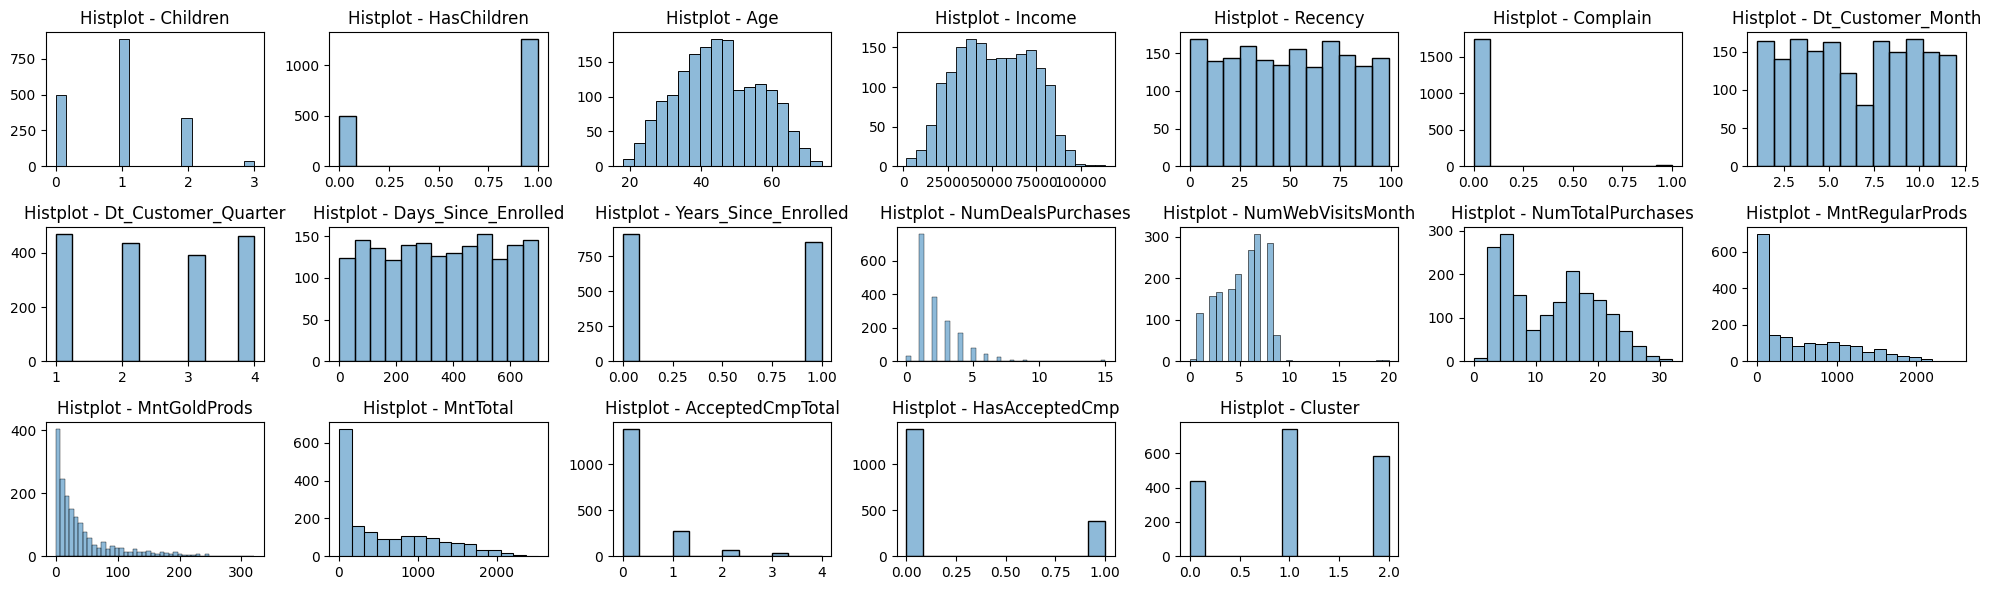

In [20]:
print('- Gráfico: Histograma.')

fn_charts_pandas.histplot(X_train_val, numerical_features, num_cols = 7, height_figsize = 2)

plt.savefig(f'../images/outputs/charts/pandas/nb08_histplot.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

### 08.3.5. Definindo o pré processamento das colunas de acordo com a distribuição dos seus dados

- **One Hot Encoder:** Indicado para colunas categóricas ou que possuem inteiros discretos.
- **Standard Scaler:** Indicado para colunas com distribuição semelhante à normal.
- **Power Transformer:** Indicado para colunas com assimetria dos dados.
- **Min-Max Scaler:** Indicado para colunas com distribuição uniforme dos dados.

In [21]:
one_hot_encoder_columns = [
    'Education',
    'Marital_Status',
    'AgeGroup',
    'Children',
    'HasChildren',
    'Complain',
    'Years_Since_Enrolled',
    'AcceptedCmpTotal',
    'HasAcceptedCmp',
    'Cluster',
]

standard_scaler_columns = [
    'Income',
    'Age',
]

power_transformer_columns = [
   'NumDealsPurchases',
   'NumWebVisitsMonth',
   'NumTotalPurchases',
   'MntRegularProds',
   'MntGoldProds',
   'MntTotal',
]

min_max_scaler_columns = [
    'Recency',
    'Dt_Customer_Month',
    'Dt_Customer_Quarter',
    'Days_Since_Enrolled',
]

### 08.3.6. Criando um pipeline dos pré processamentos que serão aplicados nas colunas

In [22]:
pipeline_pre_processing = ColumnTransformer([

    ('one_hot_encoder', OneHotEncoder(), one_hot_encoder_columns),

    ('standard_scaler', StandardScaler(), standard_scaler_columns),

    ('power_transformer', PowerTransformer(), power_transformer_columns),

    ('min_max_scaler', MinMaxScaler(), min_max_scaler_columns)

])

### 08.3.7. Definindo o Grid Search

In [23]:
grid_search = GridSearchCV(

    Pipeline([
            
        ('pre_processing', pipeline_pre_processing),

        ('feature_selection', SelectKBest(score_func = f_classif, k = 10)),
        
        ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),
        
        ('models', LogisticRegression(random_state = consts.RANDOM_STATE)),
        
    ]),
    
    {

        'feature_selection__k': [10, 15, 20, 25],

        'models__C': np.logspace(-3, 3, 7),

        'models__solver': ['liblinear', 'lbfgs', 'saga'],

        'models__penalty': ['l1', 'l2', 'elasticnet', 'none']
        
    },
    
    scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'],
    
    n_jobs = -2,
    
    refit = 'average_precision'

)

### 08.3.8. Encontrando a melhor combinação de hiperparâmetros

In [24]:
warnings.filterwarnings('ignore')

grid_search.fit(X_train_val, y_train_val)

GridSearchCV(estimator=Pipeline(steps=[('pre_processing',
                                        ColumnTransformer(transformers=[('one_hot_encoder',
                                                                         OneHotEncoder(),
                                                                         ['Education',
                                                                          'Marital_Status',
                                                                          'AgeGroup',
                                                                          'Children',
                                                                          'HasChildren',
                                                                          'Complain',
                                                                          'Years_Since_Enrolled',
                                                                          'AcceptedCmpTotal',
                                                                          'HasAcceptedCmp',
                                                                          'Cluster']),
                                                                        ('standard_scaler',
                                                                         StandardScaler(),
                                                                         ['Income',
                                                                          'Age']),
                                                                        ('power_transformer',
                                                                         Pow...
                                        LogisticRegression(random_state=42))]),
             n_jobs=-2,
             param_grid={'feature_selection__k': [10, 15, 20, 25],
                         'models__C': array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03]),
                         'models__penalty': ['l1', 'l2', 'elasticnet', 'none'],
                         'models__solver': ['liblinear', 'lbfgs', 'saga']},
             refit='average_precision',
             scoring=['accuracy', 'precision', 'recall', 'roc_auc',
                      'average_precision'])

### 08.3.9. Listando os melhores hiperparâmetros

In [25]:
grid_search.best_params_

{'feature_selection__k': 25,
 'models__C': np.float64(1000.0),
 'models__penalty': 'l2',
 'models__solver': 'saga'}

### 08.3.10. Criando o pipeline final

In [26]:
pipeline_final = Pipeline([

    ('pre_processing', pipeline_pre_processing),

    ('feature_selection', SelectKBest(score_func = f_classif, k = grid_search.best_params_['feature_selection__k'])),

    ('resampling', RandomUnderSampler(random_state = consts.RANDOM_STATE)),
    
    ('models', LogisticRegression(

        random_state = consts.RANDOM_STATE,

        C = grid_search.best_params_['models__C'],

        penalty = grid_search.best_params_['models__penalty'],

        solver = grid_search.best_params_['models__solver'],

    )),
    
])

### 08.3.11. Treinando o modelo final

In [27]:
pipeline_final.fit(X_train_val, y_train_val)

Pipeline(steps=[('pre_processing',
                 ColumnTransformer(transformers=[('one_hot_encoder',
                                                  OneHotEncoder(),
                                                  ['Education',
                                                   'Marital_Status', 'AgeGroup',
                                                   'Children', 'HasChildren',
                                                   'Complain',
                                                   'Years_Since_Enrolled',
                                                   'AcceptedCmpTotal',
                                                   'HasAcceptedCmp',
                                                   'Cluster']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['Income', 'Age']),
                                                 ('power_transformer',
                                                  PowerTransformer(),
                                                  ['NumDe...
                                                   'NumTotalPurchases',
                                                   'MntRegularProds',
                                                   'MntGoldProds',
                                                   'MntTotal']),
                                                 ('min_max_scaler',
                                                  MinMaxScaler(),
                                                  ['Recency',
                                                   'Dt_Customer_Month',
                                                   'Dt_Customer_Quarter',
                                                   'Days_Since_Enrolled'])])),
                ('feature_selection', SelectKBest(k=25)),
                ('resampling', RandomUnderSampler(random_state=42)),
                ('models',
                 LogisticRegression(C=np.float64(1000.0), random_state=42,
                                    solver='saga'))])

### 08.3.12. Aplicando o pipeline no modelo final

In [28]:
scores_final = cross_validate(

    pipeline_final,
    
    X_train_val,
    
    y_train_val,

    cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = consts.RANDOM_STATE),

    scoring = ['accuracy', 'precision', 'recall', 'roc_auc', 'average_precision'],
    
    n_jobs = -2,

)

### 08.3.13. Comentando as ações realizadas para evitar overfitting e underfitting no modelo

- **Feature Selection:** No aspecto de Feature Selection, foi aplicado o SelectKBest para selecionar as melhores features (colunas) para a criação do modelo, de modo que estivessem somente as features mais relevantes para o modelo e que não houvesse dados redundantes.
- **Balanceamento de Classes:** No aspecto de Balanceamento de Classes, como o dataset do projeto é desbalanceado, foi aplicado a técnica de Random Under Sampling (RUS) para se equiparar os valores da classe target ('Response'), onde se reduz a quantidade de valores da classe majoritária até que fique igual aos valores da classe minoritária.
- **Validação Cruzada:** No aspecto de Validação Cruzada, foi aplicado o Stratified K-Fold, por ser um dataset desbalanceado, para dividir o conjunto de treinamento em várias partes (folds) e realizar o treinamento e validação do modelo em combinações diferentes desses folds, de modo que se obtém resultados mais confiáveis das métricas de avaliação do modelo e reduz o viés associado a uma única divisão do conjunto de treinamento.
- **Regularização:** No aspecto de Regularização, foi aplicado a regularização L2 (Ridge) para adicionar uma penalidade ao modelo com base no coeficientes dos parâmetros, de modo que os coeficientes se tornem muito grandes e assim reduzindo o overfitting.
- **Otimização de Hiperparâmetros:** No aspecto de Otimização de Hiperparâmetros, foi aplicado o Grid Search para se combinar os melhores parâmetros das etapas do pipeline, de modo que se obtenha os melhores resultados nas métricas de avaliação para ter um modelo com boa performance e evitar o overfitting.

## 08.4. Comparação entre as versões do modelo

### 08.4.1. Criando um dataset com as métricas iniciais e finais do treinamento do modelo

In [29]:
df_models_metrics = pd.read_csv(consts.DATASET_MODELS_METRICS_PANDAS)

df_initial_metrics = (df_models_metrics.loc[df_models_metrics['Model'] == 'LogisticRegression', ['Accuracy', 'Precision', 'Recall', 'ROC AUC', 'Average Precision', 'Time']].assign(Results = 'Initial'))

df_initial_metrics = df_initial_metrics[['Results', 'Accuracy', 'Precision', 'Recall', 'ROC AUC', 'Average Precision', 'Time']]

df_final_metrics = pd.DataFrame(scores_final).assign(Time = lambda df: df['fit_time'] + df['score_time'], Results = 'Final')

df_final_metrics = df_final_metrics.rename(columns = lambda c: c.replace('test_', ''))

df_final_metrics = df_final_metrics.drop(columns = ['fit_time', 'score_time'])

df_final_metrics = df_final_metrics.reindex(columns = ['Results', 'accuracy', 'precision', 'recall', 'roc_auc', 'average_precision', 'Time'])

df_final_metrics = df_final_metrics.rename(columns = {'accuracy': 'Accuracy', 'precision': 'Precision', 'recall': 'Recall', 'roc_auc': 'ROC AUC', 'average_precision': 'Average Precision'})

df_model_growth = pd.concat([df_initial_metrics, df_final_metrics], ignore_index = True)

df_model_growth.to_csv(consts.DATASET_MODEL_GROWTH_PANDAS, index = False)

df_model_growth

,Results,Accuracy,Precision,Recall,ROC AUC,Average Precision,Time
0,Initial,0.756374,0.356522,0.773585,0.851101,0.517501,0.110678
1,Initial,0.801700,0.408602,0.716981,0.860000,0.641582,0.102520
2,Initial,0.779037,0.349398,0.547170,0.788962,0.460684,0.104579
3,Initial,0.750708,0.365079,0.851852,0.859284,0.559060,0.109230
4,Initial,0.755682,0.345794,0.698113,0.845081,0.594987,0.097324
5,Final,0.745042,0.339130,0.735849,0.856195,0.507861,0.088315
6,Final,0.841360,0.482353,0.773585,0.895409,0.670227,0.088889
7,Final,0.813031,0.434343,0.811321,0.886761,0.634682,0.114425
8,Final,0.796034,0.416667,0.833333,0.879661,0.597900,0.099782
9,Final,0.798295,0.410000,0.773585,0.876696,0.624893,0.092296


### 08.4.2. Criando diagramas de caixa para comparar as métricas do modelo antes e depois da otimização de hiperparâmetros

- Gráfico: Diagrama de Caixa.


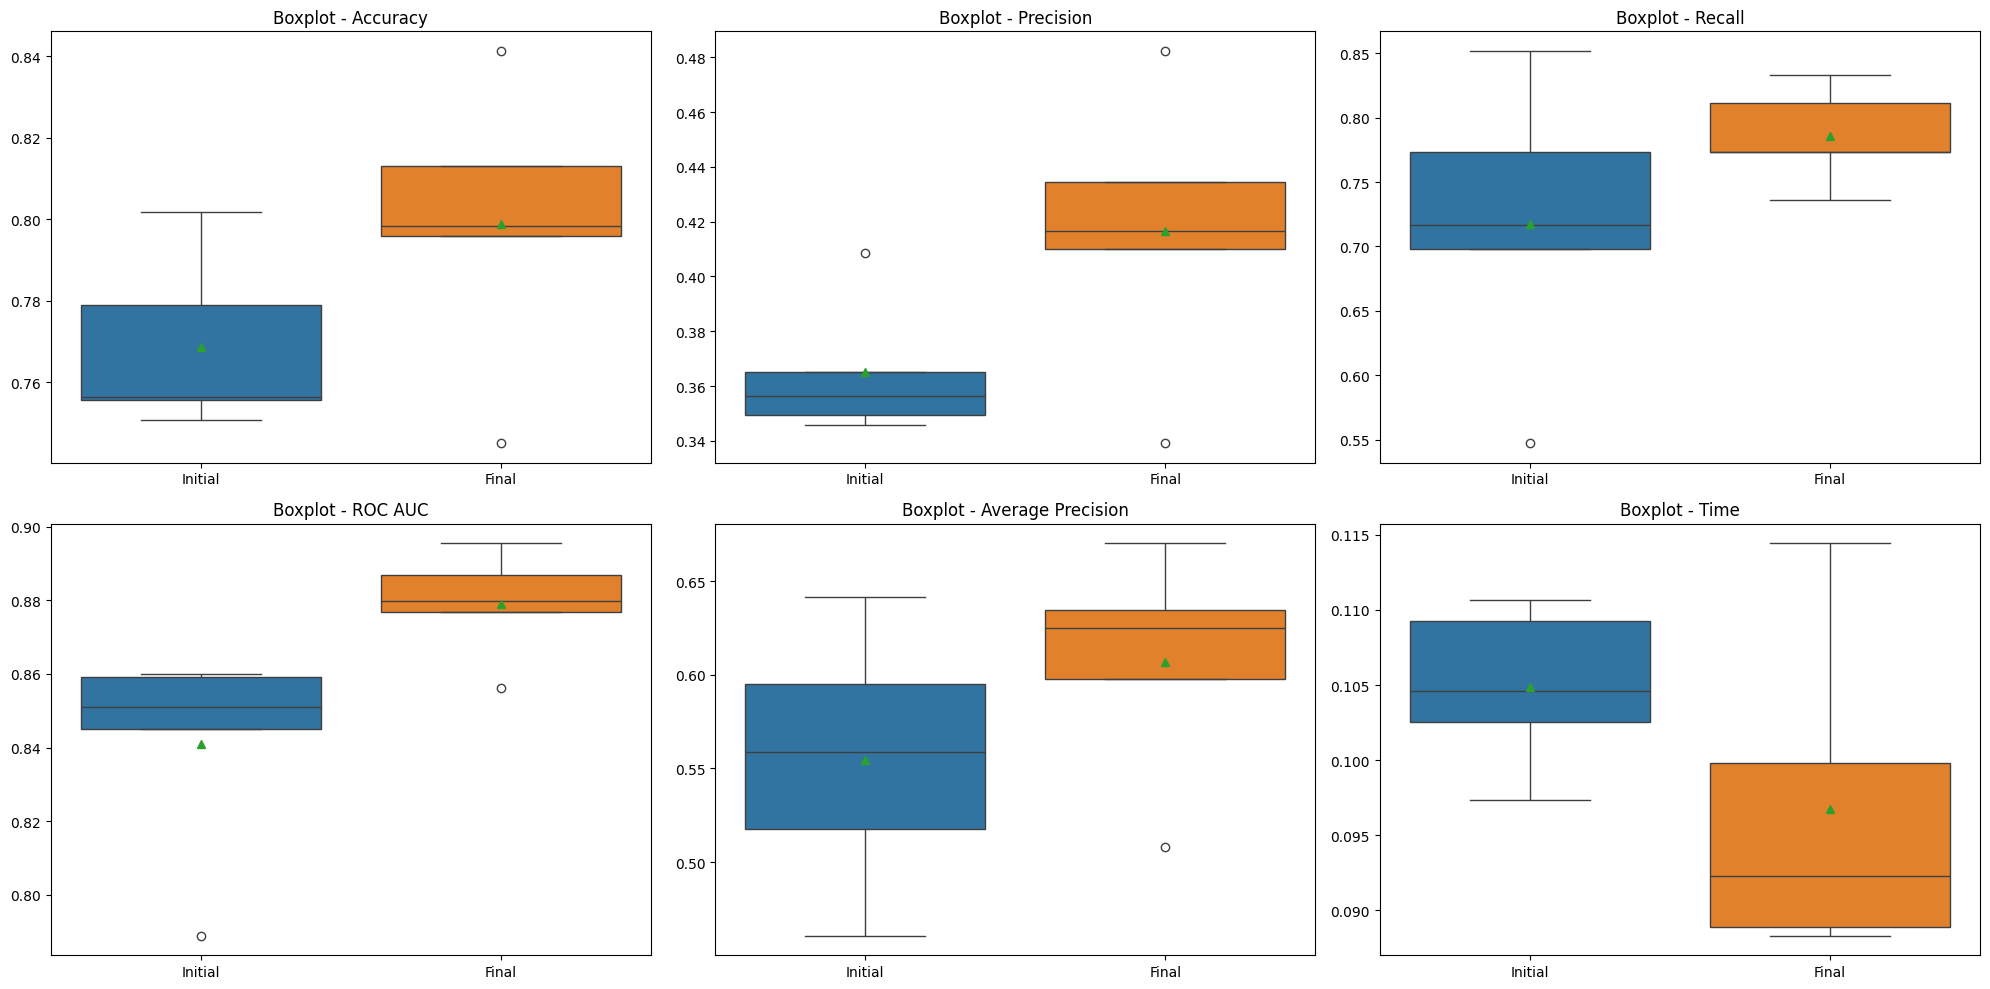

In [30]:
print('- Gráfico: Diagrama de Caixa.')

fn_charts_pandas.boxplot(df_model_growth, df_model_growth.columns[1:].to_list(), 'Results', 'Results')

plt.savefig(f'../images/outputs/charts/pandas/nb08_boxplot_models.png', format = 'png', dpi = 75, bbox_inches = 'tight', transparent = True)

plt.show()

## 08.5. Aplicação do modelo aos dados de teste

### 08.5.1. Realizando as previsões com os dados de teste

In [31]:
y_pred = pipeline_final.predict(X_test)

y_prob = pipeline_final.predict_proba(X_test)[:, 1]

In [32]:
df_confusion_matrix = pd.DataFrame(

    confusion_matrix(y_test, y_pred),

    index = ['Real Negativo', 'Real Positivo'],

    columns = ['Previsto Negativo', 'Previsto Positivo']
    
)

df_confusion_matrix

,Previsto Negativo,Previsto Positivo
Real Negativo,306,68
Real Positivo,19,48


### 08.5.2. Calculando as métricas de desempenho com os dados de teste

In [33]:
accuracy_test = accuracy_score(y_test, y_pred)

precision_test = precision_score(y_test, y_pred)

recall_test = recall_score(y_test, y_pred)

roc_auc_test = roc_auc_score(y_test, y_prob)

average_precision_test = average_precision_score(y_test, y_prob)

### 08.5.3. Calculando as métricas de desempenho com os dados de treino e validação

In [34]:
accuracy_train_val = df_model_growth['Accuracy'].mean()

precision_train_val = df_model_growth['Precision'].mean()

recall_train_val = df_model_growth['Recall'].mean()

roc_auc_train_val = df_model_growth['ROC AUC'].mean()

average_precision_train_val = df_model_growth['Average Precision'].mean()

### 08.5.4. Criando um dataset comparativo entre as métricas dos dados de treino e validação e dos dados de teste

In [35]:
df_comparing_metrics = pd.DataFrame({
    'Dados de Treino e Validação': [accuracy_train_val, precision_train_val, recall_train_val, roc_auc_train_val, average_precision_train_val],
    'Dados de Teste': [accuracy_test, precision_test, recall_test, roc_auc_test, average_precision_test],
}, index = ['Accuracy', 'Precision', 'Recall', 'ROC AUC', 'Average Precision'])

df_comparing_metrics = df_comparing_metrics.reset_index()

df_comparing_metrics.columns = ['Métricas de Desempenho', 'Dados de Treino e Validação', 'Dados de Teste']

df_comparing_metrics.to_csv(consts.DATASET_COMPARING_METRICS_PANDAS, index = False)

df_comparing_metrics[['Dados de Treino e Validação', 'Dados de Teste']] = ((df_comparing_metrics[['Dados de Treino e Validação', 'Dados de Teste']] * 100).round(2).astype(str).add('%'))

df_comparing_metrics

,Métricas de Desempenho,Dados de Treino e Validação,Dados de Teste
0,Accuracy,78.37%,80.27%
1,Precision,39.08%,41.38%
2,Recall,75.15%,71.64%
3,ROC AUC,85.99%,87.25%
4,Average Precision,58.09%,62.19%


### 08.5.5. Analisando a comparação entre as métricas e classificando o modelo entre overfitting, underfitting ou good fit

**- Overfitting:** O overfitting acontece quando o modelo "decora" os dados de treino. O sintoma clássico é ter métricas altíssimas na validação (ex: 95%) e uma queda brusca nos dados de teste (ex: 60%).

**- Underfitting:** O underfitting ocorre quando o modelo é muito simples e não consegue aprender os padrões dos dados, resultando em métricas ruins tanto no treino quanto no teste (ex: tudo na casa dos 50%, como um cara-ou-coroa).

**- Good Fit:** O good fit acontece quando o modelo realmente aprende a lógica central dos dados, ignorando os ruídos e exceções passageiras. O sintoma clássico é apresentar métricas sólidas na validação e conseguir mantê-las consistentes e praticamente intactas nos dados inéditos de teste (ex: 85% na validação e 84% no teste, provando sua estabilidade).

**Classificação Final:**
<br>
De acordo com a análise das métricas de desempenho do modelo entre os dados de treino e validação e os dados de teste, esse modelo é classificado como **Good Fit** pois apresenta resultados consistentes e coerentes nos dados de teste em comparação aos dados de treino e validação, sem apresentar nenhum sinal de overfitting ou underfitting.

## 08.6. Exportação do modelo otimizado

### 08.6.1. Salvando o grid search completo para auditoria e reprodutibilidade

In [36]:
joblib.dump(grid_search, consts.GRID_SEARCH_CLASSIFICATION_PANDAS_JOBLIB)

['../models/grid_search_classification_pandas.joblib']

### 08.6.2. Salvando o modelo final treinado com os melhores parâmetros encontrados pelo Grid Search nos formatos joblib e pkl

In [37]:
joblib.dump(pipeline_final, consts.MODEL_CLASSIFICATION_PANDAS_JOBLIB)

['../models/model_classification_pandas.joblib']

In [38]:
joblib.dump(pipeline_final, consts.MODEL_CLASSIFICATION_PANDAS_PKL)

['../models/model_classification_pandas.pkl']